In [1]:
import numpy as np
import pandas as pd
from scipy import stats

from matplotlib import pyplot as plt
import seaborn as sns

alpha = 0.05

In [2]:
data = pd.read_csv("_data_.csv")
test = data[data["group"] == "test"]["data"].values
control = data[data["group"] == "control"]["data"].values

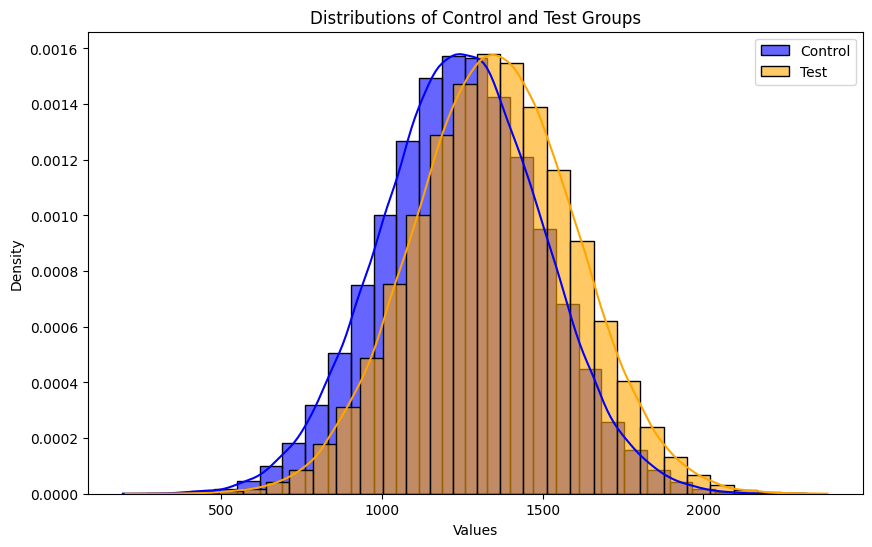

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(
    control,
    kde=True,
    color="blue",
    label="Control",
    stat="density",
    bins=30,
    alpha=0.6,
)
sns.histplot(
    test,
    kde=True,
    color="orange",
    label="Test",
    stat="density",
    bins=30,
    alpha=0.6,
)

plt.title("Distributions of Control and Test Groups")
plt.xlabel("Values")
plt.ylabel("Density")
plt.legend()
plt.show()

# Тест Стьюдента

In [4]:
statistic, p_value = stats.ttest_ind(test, control, equal_var=False)
print(f"T-statistic: {statistic}, P-value: {p_value}")

if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Reject the alternative hypothesis")

T-statistic: 91.87679853859926, P-value: 0.0
Reject the null hypothesis


# Бутстрап
С перцентильным типом ДИ 

In [5]:
def bootstrap(data: np.ndarray, n: int = 1000) -> np.ndarray:
    n_samples = len(data)
    return np.random.choice(data, size=(n, n_samples), replace=True)


control_bootstrap = bootstrap(control)
test_bootstrap = bootstrap(test)

control_means = np.mean(control_bootstrap, axis=1)
test_means = np.mean(test_bootstrap, axis=1)

diffs_mean = test_means - control_means
ci_mean = np.quantile(diffs_mean, [alpha * 0.5, 1 - alpha * 0.5])

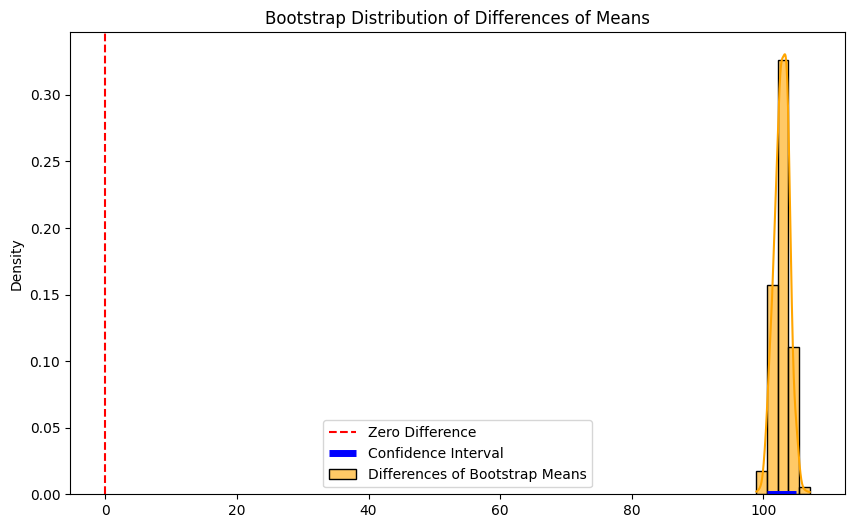

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(
    diffs_mean,
    kde=True,
    color="orange",
    label="Differences of Bootstrap Means",
    stat="density",
    bins=5,
    alpha=0.6,
)
plt.axvline(x=0, color="red", linestyle="--", label="Zero Difference")
plt.hlines(
    y=0,
    xmin=ci_mean[0],
    xmax=ci_mean[1],
    colors="blue",
    linestyles="solid",
    label="Confidence Interval",
    linewidth=5,
)
plt.title("Bootstrap Distribution of Differences of Means")
plt.legend()
plt.show()

In [7]:
print(
    f"{(1 - alpha) * 100:.0f}% Confidence Interval of Difference of Means: {ci_mean}"
)
p_value = np.mean(diffs_mean < 0)
p_value = min(p_value, 1 - p_value)
print(f"P-value: {p_value}")

if ci_mean[0] > 0 or ci_mean[1] < 0:
    print("Reject the null hypothesis")
else:
    print("Reject the alternative hypothesis")

95% Confidence Interval of Difference of Means: [100.50952112 105.00623657]
P-value: 0.0
Reject the null hypothesis


# Сравнение методов

Методы выдают одинаковый результат, отклоняя нулевую гипотезу о равенстве средних значений, и в обоих случаях тест получается довольно мощный: `p-value` оказалось равным нулю. 

Но в данной задаче лучше использовать тест Стьюдента, так как данные в обеих группах имеют нормальное распределение и их дисперсии (исходя из графиков) примерно равны, так что тест будет выдавать корректный результат. А бутстрап намного более вычислительно затратный, и в ситуации, когда можно использовать более простой тест, его не стоит применять

# Тест на равенство 90% квантилей

In [8]:
control_quantiles = np.quantile(control_bootstrap, 0.9, axis=1)
test_quantiles = np.quantile(test_bootstrap, 0.9, axis=1)

diffs_quantile = test_quantiles - control_quantiles
ci_quantile = np.quantile(diffs_quantile, [alpha * 0.5, 1 - alpha * 0.5])


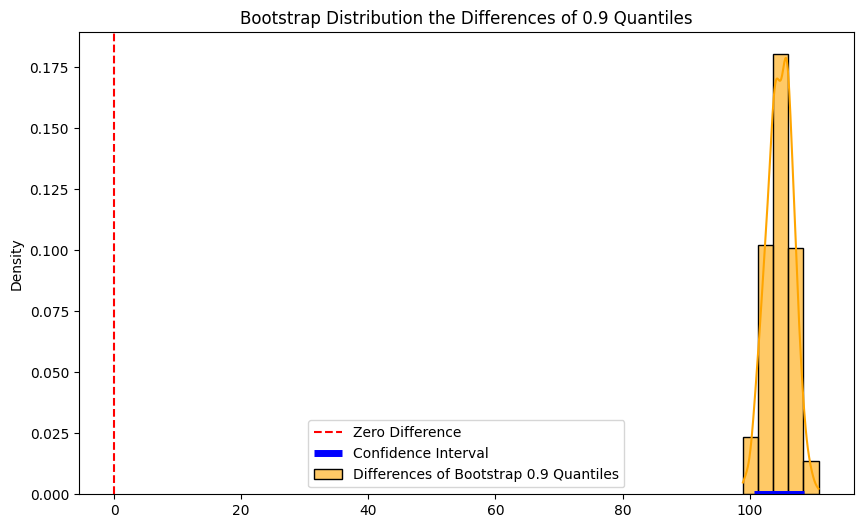

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(
    diffs_quantile,
    kde=True,
    color="orange",
    label="Differences of Bootstrap 0.9 Quantiles",
    stat="density",
    bins=5,
    alpha=0.6,
)
plt.axvline(x=0, color="red", linestyle="--", label="Zero Difference")
plt.hlines(
    y=0,
    xmin=ci_quantile[0],
    xmax=ci_quantile[1],
    colors="blue",
    linestyles="solid",
    label="Confidence Interval",
    linewidth=5,
)
plt.title("Bootstrap Distribution the Differences of 0.9 Quantiles")
plt.legend()
plt.show()

In [10]:
print(
    f"{(1 - alpha) * 100:.0f}% Confidence Interval for Difference of 0.9 Quantiles: {ci_quantile}"
)

p_value = np.mean(diffs_quantile < 0)
p_value = min(p_value, 1 - p_value)
print(f"P-value: {p_value}")

if ci_quantile[0] > 0 or ci_quantile[1] < 0:
    print("Reject the null hypothesis")
else:
    print("Reject the alternative hypothesis")

95% Confidence Interval for Difference of 0.9 Quantiles: [100.73589914 108.54063518]
P-value: 0.0
Reject the null hypothesis
